## 03 Procesamiento de Data

1. Revisión de datos (primeros 5 y ultimos 5)
2. Eliminación de datos que no son relevantes en base a la exploración
3. Ingeniería de atributos
4. Separacion de variables categoricas y numericas
5. Variables numéricas
   1. Identificación de Outliers (Z-Score o IQR)
   2. Imputación de Nulos mediante Random forest regresor
   3. Medimos la correlación de varibales numéricas
6. Variables Categóricas
   1. Imputación de Nulos
   2. Medimos la correlación (Chi-cuadrado) 
7. Unión de datos trabajados
8. Guardado de datos preprocesados.

In [6]:
import pandas as pd

data_row = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')

df_prep = data_row.copy()

In [8]:
df_prep.head(5)

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,...,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,...,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,...,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,...,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,...,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [9]:
# Eliminamos las oclumnas que no nos sirven

df_prep.drop(columns= ['ID', 'NOMBRE_PEAJE'] , axis=1, inplace=True)

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,...,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,...,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,...,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,...,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,...,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,...,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [29]:
# Feature Enginnering

df_prep['Pandemia'] = df_prep['PERIODO'].apply(lambda x: 1 if x in {202003, 202004, 202005, 202006, 202007} else 0 )


df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,...,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,Pandemia
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,...,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,0
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,...,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,0
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,...,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,0
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,...,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,0
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,...,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,0


In [30]:
# Separacion de variables por numericas y categoricas

df_prep_num = df_prep.select_dtypes(include=['int64', 'float64','number'])
df_prep_cat = df_prep.select_dtypes(include=['object', 'category'])

### Trabajamos las variables numéricas

In [32]:
# Identificamos outliers numéricos

# Podemos usar z-score (Cuando tenemos gran cantidad de datos y una distribución normal) o iqr (Cuando la cantida de datos es pqueñay tiene una tendencia hacia un lado.)
Q1 = df_prep_num.quantile(0.25)
Q3 = df_prep_num.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_prep_filtered_num = df_prep_num[(df_prep_num > lower_bound) & (df_prep_num < upper_bound)]

df_prep_filtered_num.count()


VEH_LIGEROS_TAR_DIF         8526
VEH_LIGEROS_AUTOMOVILES     9645
VEH_PESADOS_TAR_DIF            0
VEH_PESADOS__2E             9728
VEH_PESADOS_3E              9386
VEH_PESADOS_4E              9648
VEH_PESADOS_5E              9632
VEH_PESADOS_6E              9767
VEH_PESADOS_7E              9767
VEH_LIGEROS_TOTAL           9622
VEH_LIGEROS_IMD             9610
VEH_PESADOS_TOTAL           9589
VEH_PESADOS_IMD             9586
VEH_TOTAL                   9779
VEH_IMD                     9783
ANIO                       10781
MES                        10781
PERIODO                    10781
Pandemia                       0
dtype: int64

In [36]:
# Imputamos Nulos.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer_num = IterativeImputer(estimator=RandomForestRegressor())

df_num_imputed = imputer_num.fit_transform(df_prep_filtered_num)

df_num_imputed

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


array([[1.74340e+02, 8.07000e+03, 2.58600e+03, ..., 2.01400e+03,
        1.00000e+00, 2.01401e+05],
       [0.00000e+00, 2.46440e+04, 6.50200e+03, ..., 2.01400e+03,
        1.00000e+00, 2.01401e+05],
       [2.69650e+02, 8.21390e+04, 1.79810e+04, ..., 2.01400e+03,
        1.00000e+00, 2.01401e+05],
       ...,
       [0.00000e+00, 3.10780e+04, 3.20900e+03, ..., 2.02500e+03,
        6.00000e+00, 2.02506e+05],
       [0.00000e+00, 4.50900e+01, 2.09100e+01, ..., 2.02500e+03,
        6.00000e+00, 2.02506e+05],
       [0.00000e+00, 1.26470e+04, 4.03900e+03, ..., 2.02500e+03,
        6.00000e+00, 2.02506e+05]])

In [40]:
df_prep_filtered_num.drop(columns=['Pandemia', 'VEH_PESADOS_TAR_DIF'])

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,NaN,8070.0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169.0,328.0,9515.0,306.9,19684.0,635.0,2014,1,201401
1,0.0,24644.0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644.0,795.0,24730.0,797.7,49374.0,1592.7,2014,1,201401
2,NaN,82139.0,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,NaN,NaN,37326.0,1204.1,153108.0,4939.0,2014,1,201401
3,10.0,46944.0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954.0,1514.6,62622.0,2020.1,109576.0,3534.7,2014,1,201401
4,0.0,23831.0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831.0,768.7,13906.0,448.6,37737.0,1217.3,2014,1,201401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10776,660.0,3609.0,808.0,603.0,605.0,2553.0,859.0,3.0,4269.0,142.3,5431.0,181.0,9700.0,323.3,2025,6,202506
10777,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,202506
10778,0.0,31078.0,3209.0,965.0,290.0,221.0,489.0,4.0,31078.0,1035.9,5178.0,172.6,36256.0,1208.5,2025,6,202506
10779,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,202506


In [44]:
df_num_imputed = pd.DataFrame(df_num_imputed, columns=df_prep_filtered_num.drop(columns=['Pandemia', 'VEH_PESADOS_TAR_DIF']).columns)

df_num_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,174.34,8070.0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169.00,328.000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0
1,0.00,24644.0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644.00,795.000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0
2,269.65,82139.0,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,87462.89,2888.186,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0
3,10.00,46944.0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954.00,1514.600,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0
4,0.00,23831.0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831.00,768.700,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0


<AxesSubplot: >

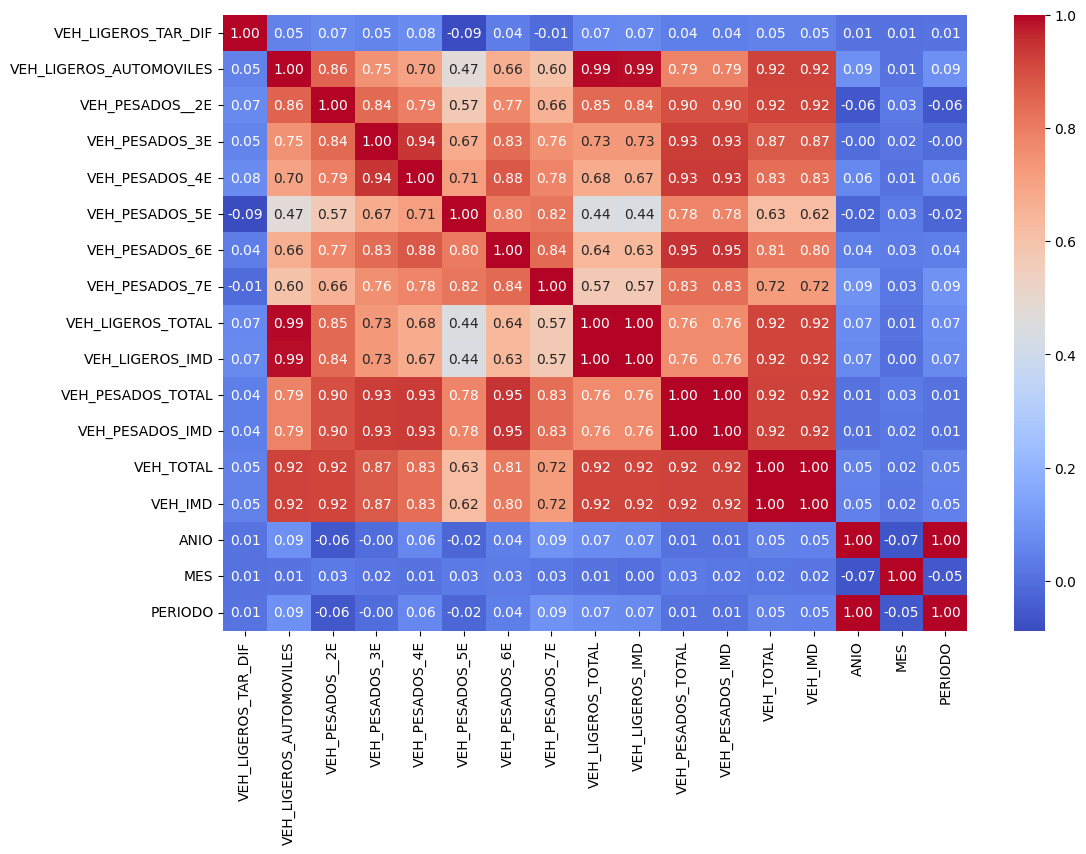

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_num_imputed.corr()
mask = plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True
)


### Variables Categóricas